
Student 1: Mobin Khatib (11114435)

Student 2: Ali Edareh Heidarabadi (110360280)


Cell 1: Imports

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Cell 2: Configuration

In [14]:
# Base directory
BASE_DIR = Path("/content/")

# Input CSV files
DEEP_SLEEP_CSV = BASE_DIR / "deep_sleep.csv"
SENDER_CSV = BASE_DIR / "sender.csv"
SENSOR_CSV = BASE_DIR / "sensor-read.csv"

# Output folder
OUTPUT_DIR = BASE_DIR / "iot_report_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Battery and Timing Parameters
BATTERY_ENERGY_J = 19435.0

In [15]:
# 1. Boot Time (T_BOOT_S):
# Calculated by finding the delta between the first wakeup timestamp in 'deep_sleep.csv'
# and the start of the first stable 251mW plateau.
# Formula: Timestamp(First_251mW) - Timestamp(Wakeup)
T_BOOT_S = 0.1

# 2. WiFi Init Time (T_WIFI_INIT_S):
# Extracted by measuring the duration of the 633mW plateau in 'deep_sleep.csv'.
# This represents the period where the radio is powered but not yet transmitting data.
# Formula: Timestamp(End_of_633mW) - Timestamp(Start_of_633mW)
T_WIFI_INIT_S = 0.19

# 3. Sensing Time (T_SENSOR_S):
# Obtained from Wokwi Serial Monitor by wrapping the sensor reading function
# with micros() calls. This reflects the actual firmware execution overhead.
T_SENSOR_S = 892.37e-6
# 4. Transmission Time (T_TX_S):
# Measured via Wokwi Serial Monitor during the ESP-NOW callback execution.
# It accounts for the time the CPU is active and the radio is in high-power TX mode.
T_TX_S = 1039.47e-6

# 5. Post-TX Idle (T_POST_TX_IDLE_S):
# Identified in 'deep_sleep.csv' as the final 251mW plateau occurring after
# WiFi activity but before the drop to the 45mW deep sleep floor.
T_POST_TX_IDLE_S = 0.05

# 6. Deep Sleep (t_sleep):
# My personal code is 11114435
DEEP_SLEEP_TIME_S = 4.0

Cell 3: Data Loading

In [16]:
def load_trace(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["t_s"] = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds()
    df = df.rename(columns={"Data": "Power_mW"})
    return df

Cell 4: Save tables in an appropriate file

In [17]:
def save_table(df: pd.DataFrame, name: str) -> None:
    csv_path = OUTPUT_DIR / f"{name}.csv"
    xlsx_path = OUTPUT_DIR / f"{name}.xlsx"
    df.to_csv(csv_path, index=False)
    df.to_excel(xlsx_path, index=False)

Power Profile Characterization

This function analyzes the raw CSV traces to identify average power consumption for each operational state.
We use **thresholding** based on the observed power levels:
- **Deep Sleep**: Power < 100mW.
- **Boot/Idle**: Stable plateau around 250mW.
- **Transmission**: High-power spikes (categorized into **2 dBm** and **19.5 dBm** for comparison).
The mean value of each plateau is calculated to minimize noise in the energy estimation.

Cell 5: Power level extraction


In [18]:
def extract_power_levels(deep_df, sensor_df, sender_df):
    p_sleep = deep_df.loc[deep_df["Power_mW"] < 100, "Power_mW"].mean()
    p_boot_idle = deep_df.loc[(deep_df["Power_mW"] >= 245) & (deep_df["Power_mW"] <= 258), "Power_mW"].mean()
    p_wifi = deep_df.loc[deep_df["Power_mW"] > 600, "Power_mW"].mean()
    p_sensor = sensor_df.loc[sensor_df["Power_mW"] > 340, "Power_mW"].mean()
    p_tx_2dbm = sender_df.loc[(sender_df["Power_mW"] >= 615) & (sender_df["Power_mW"] <= 625), "Power_mW"].mean()
    p_tx_19_5dbm = sender_df.loc[sender_df["Power_mW"] >= 650, "Power_mW"].mean()

    return {
        "Boot": p_boot_idle,
        "Sensor Reading": p_sensor,
        "Wi-Fi On / ESP-NOW Init": p_wifi,
        "Transmission (2 dBm)": p_tx_2dbm,
        "Transmission (19.5 dBm)": p_tx_19_5dbm,
        "Post-TX Idle (modeled)": p_boot_idle,
        "Deep Sleep": p_sleep,
    }

Cell 6: Awake phase table

System Timing & Battery Parameters

In this section, we define the fixed timing parameters extracted from the **Wokwi simulation** and the **ST datasheet**.
- `T_BOOT_S`: Time taken for the ESP32 to wake up and start executing the first instruction.
- `T_SENSOR_S`: Duration of the sensor reading phase via I2C/SPI.
- `T_TX_S`: Time required to transmit the ESP-NOW packet.
- `BATTERY_ENERGY_J`: Total usable energy of the battery (19435 Joules) as per project requirements.

Awake Phase Energy Analysis

The "Awake" phase is the most energy-intensive part of the cycle. We calculate the **Time-Weighted Average Power** using the formula:
$$P_{avg, awake} = \frac{\sum (Power_{state} \times Duration_{state})}{\sum Duration_{state}}$$
This table provides a breakdown of how energy is distributed across Boot, Sensing, and Communication phases before the device returns to Deep Sleep.

In [19]:
def build_awake_table(power_levels, tx_mode="2 dBm"):
    tx_key = f"Transmission ({tx_mode})"
    rows = [
        {"Phase / state": "Boot", "Avg. power (mW)": power_levels["Boot"], "Duration (s)": T_BOOT_S},
        {"Phase / state": "Sensor Reading", "Avg. power (mW)": power_levels["Sensor Reading"], "Duration (s)": T_SENSOR_S},
        {"Phase / state": "Wi-Fi On / ESP-NOW Init", "Avg. power (mW)": power_levels["Wi-Fi On / ESP-NOW Init"], "Duration (s)": T_WIFI_INIT_S},
        {"Phase / state": tx_key, "Avg. power (mW)": power_levels[tx_key], "Duration (s)": T_TX_S},
        {"Phase / state": "Post-TX Idle (modeled)", "Avg. power (mW)": power_levels["Post-TX Idle (modeled)"], "Duration (s)": T_POST_TX_IDLE_S},
    ]
    df = pd.DataFrame(rows)
    total_awake_time = df["Duration (s)"].sum()
    total_awake_energy = (df["Avg. power (mW)"] * df["Duration (s)"]).sum()

    summary_row = pd.DataFrame([{"Phase / state": "Total Awake Time", "Avg. power (mW)": total_awake_energy / total_awake_time, "Duration (s)": total_awake_time}])
    return pd.concat([df, summary_row], ignore_index=True)

Cell 7: Cycle energy table

In [20]:
def build_cycle_energy_table(power_levels, tx_mode="2 dBm"):
    tx_key = f"Transmission ({tx_mode})"
    rows = [
        ("Boot", power_levels["Boot"], T_BOOT_S),
        ("Sensor Reading", power_levels["Sensor Reading"], T_SENSOR_S),
        ("Wi-Fi On / ESP-NOW Init", power_levels["Wi-Fi On / ESP-NOW Init"], T_WIFI_INIT_S),
        (tx_key, power_levels[tx_key], T_TX_S),
        ("Post-TX Idle", power_levels["Post-TX Idle (modeled)"], T_POST_TX_IDLE_S),
        ("Deep Sleep", power_levels["Deep Sleep"], DEEP_SLEEP_TIME_S),
    ]
    df = pd.DataFrame(rows, columns=["State", "Power (mW)", "Duration (s)"])
    df["Energy (mJ)"] = df["Power (mW)"] * df["Duration (s)"]
    total_energy = df["Energy (mJ)"].sum()
    df["Share (%)"] = 100 * df["Energy (mJ)"] / total_energy

    total_row = pd.DataFrame([{"State": "Total", "Duration (s)": df["Duration (s)"].sum(), "Energy (mJ)": total_energy, "Share (%)": 100.0}])
    return pd.concat([df, total_row], ignore_index=True)

Cell 8: Battery Lifetime

Battery Lifetime Prediction
The final step is to estimate the total operational life of the device.
We calculate the **Total Energy per Cycle** ($E_{cycle} = E_{awake} + E_{sleep}$) and then determine how many such cycles the battery can sustain:
1. **Total Cycles** = $Battery Energy (J) / E_{cycle} (J)$
2. **Lifetime (hours)** = $(Total Cycles \times Cycle Duration) / 3600$
This allows us to compare the impact of different TX power levels on the long-term autonomy of the IoT node.

In [21]:
def lifetime_from_cycle(cycle_table):
    total_row = cycle_table.loc[cycle_table["State"] == "Total"].iloc[0]
    e_cycle_j = total_row["Energy (mJ)"] / 1000.0
    n_cycles = BATTERY_ENERGY_J / e_cycle_j
    t_life_h = (n_cycles * total_row["Duration (s)"]) / 3600.0
    return pd.DataFrame([{"Battery energy (J)": BATTERY_ENERGY_J, "Cycle energy (J)": e_cycle_j, "Estimated lifetime (h)": t_life_h}])

Cell 9: Plotting

In [22]:
def plot_all_results(deep_df, sender_df, sensor_df, cycle_baseline, cycle_improved, power_levels):
    # 1. Overview Traces
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    axes[0].plot(deep_df["t_s"], deep_df["Power_mW"]); axes[0].set_title("Deep Sleep Trace")
    axes[1].plot(sender_df["t_s"], sender_df["Power_mW"]); axes[1].set_title("Sender Trace")
    axes[2].plot(sensor_df["t_s"], sensor_df["Power_mW"]); axes[2].set_title("Sensor Trace")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "power_traces_overview.png")

    # 2. Energy Breakdown (Baseline)
    plt.figure(figsize=(8, 5))
    temp_df = cycle_baseline[cycle_baseline["State"] != "Total"]
    plt.bar(temp_df["State"], temp_df["Energy (mJ)"])
    plt.xticks(rotation=30); plt.title("Cycle Energy Breakdown (19.5 dBm)")
    plt.savefig(OUTPUT_DIR / "energy_breakdown_baseline_19_5dbm.png")

    # 3. TX Comparison
    plt.figure(figsize=(6, 4))
    plt.bar(["19.5 dBm", "2 dBm"], [power_levels["Transmission (19.5 dBm)"]*T_TX_S, power_levels["Transmission (2 dBm)"]*T_TX_S])
    plt.title("TX Energy Comparison"); plt.ylabel("Energy (mJ)")
    plt.savefig(OUTPUT_DIR / "tx_energy_compare.png")

Cell 10: Execution - Baseline & Improved

In [23]:
deep_df = load_trace(DEEP_SLEEP_CSV)
sender_df = load_trace(SENDER_CSV)
sensor_df = load_trace(SENSOR_CSV)
power_levels = extract_power_levels(deep_df, sensor_df, sender_df)

# Baseline (19.5 dBm)
awake_baseline = build_awake_table(power_levels, "19.5 dBm")
cycle_baseline = build_cycle_energy_table(power_levels, "19.5 dBm")
life_baseline = lifetime_from_cycle(cycle_baseline)
save_table(awake_baseline, "awake_table_baseline_19_5dbm")
save_table(cycle_baseline, "cycle_energy_baseline_19_5dbm")
save_table(life_baseline, "lifetime_baseline_19_5dbm")

# Improved (2 dBm)
awake_improved = build_awake_table(power_levels, "2 dBm")
cycle_improved = build_cycle_energy_table(power_levels, "2 dBm")
life_improved = lifetime_from_cycle(cycle_improved)
save_table(awake_improved, "awake_table_improved_2dbm")
save_table(cycle_improved, "cycle_energy_improved_2dbm")
save_table(life_improved, "lifetime_improved_2dbm")

print("Calculations complete. Files saved.")

Calculations complete. Files saved.


Cell 11: Final Plots

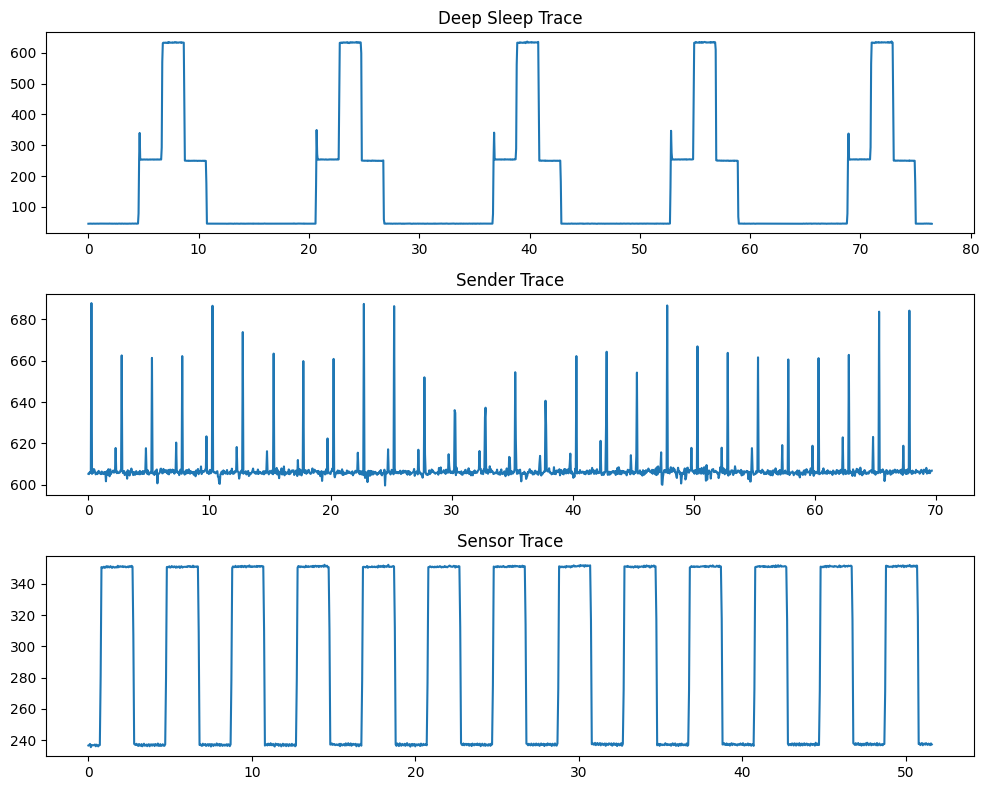

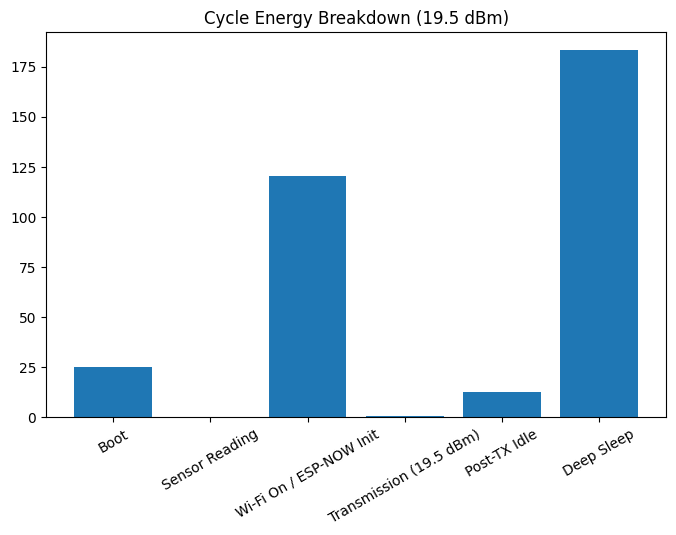

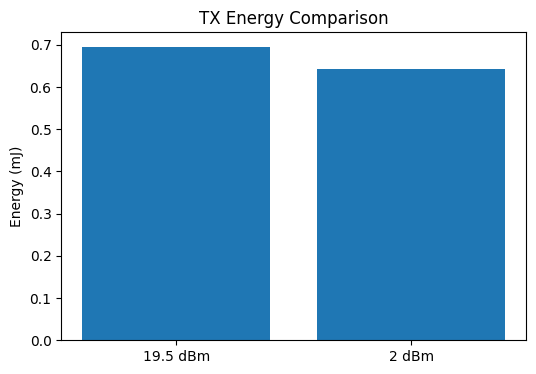

In [24]:
plot_all_results(deep_df, sender_df, sensor_df, cycle_baseline, cycle_improved, power_levels)
plt.show()

Cell 10: Execution - Baseline & Improved